In [2]:
import numpy as np
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.wcs import WCS   # In order to get the shift for overlaying frames

import sep

from os import listdir

from mgefit.find_galaxy import find_galaxy

# from sourcemasking import obtainSextractorSources

In [49]:
hdul = fits.open('ERO-Dorado/Euclid-VIS-ERO-Dorado-Flattened.DR3.fits/Euclid-VIS-ERO-Dorado-Flattened.v3.fits')
hdul.info()

full_data = hdul[0].data
full_header = hdul[0].header

hdul.close()

Filename: ERO-Dorado/Euclid-VIS-ERO-Dorado-Flattened.DR3.fits/Euclid-VIS-ERO-Dorado-Flattened.v3.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      85   (36000, 36000)   float32   


In [50]:
coorx, coory = 27662, 20615
size = 1000

field = full_data[coory-size:coory+size, coorx-size:coorx+size]

fits.writeto('cfield.fits', field, header=full_header, overwrite=True)

In [ ]:
hdul = fits.open('ERO-Dorado/Euclid-VIS-ERO-Dorado-Flattened.DR3.fits/Euclid-VIS-ERO-Dorado-Flattened.v3.fits')
hdul.info()

full_data = hdul[0].data
full_header = hdul[0].header

hdul.close()

Filename: ERO-Dorado/Euclid-VIS-ERO-Dorado-Flattened.DR3.fits/Euclid-VIS-ERO-Dorado-Flattened.v3.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      85   (36000, 36000)   float32   


In [7]:
full_header

SIMPLE  =                    T / This is a FITS file                            
BITPIX  =                  -32 /                                                
NAXIS   =                    2 /                                                
NAXIS1  =                36000 / NUMBER OF ELEMENTS ALONG THIS AXIS             
NAXIS2  =                36000 / NUMBER OF ELEMENTS ALONG THIS AXIS             
EXTEND  =                    T / This file may contain FITS extensions          
EQUINOX =        2000.00000000 / Mean equinox                                   
RADESYS = 'ICRS    '           / Astrometric system                             
CTYPE1  = 'RA---TAN'           / WCS projection type for this axis              
CUNIT1  = 'deg     '           / Axis unit                                      
CRVAL1  =   6.401433700000E+01 / World coordinate on this axis                  
CRPIX1  =   1.800050000000E+04 / Reference pixel on this axis                   
CD1_1   =  -2.777777777778E-

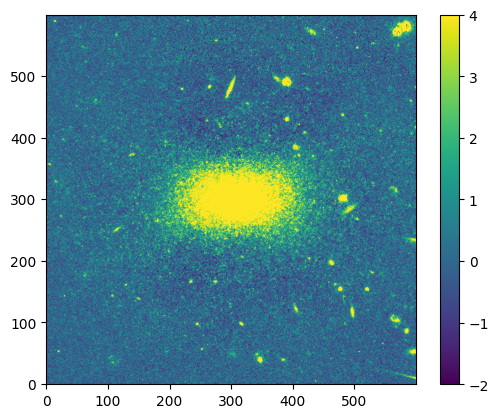

In [15]:
coorx, coory = 27662, 20615
size = 300

data = full_data[coory-size:coory+size, coorx-size:coorx+size]

plt.imshow(data, origin='lower', vmin=-2, vmax=4)
plt.colorbar()
plt.show()

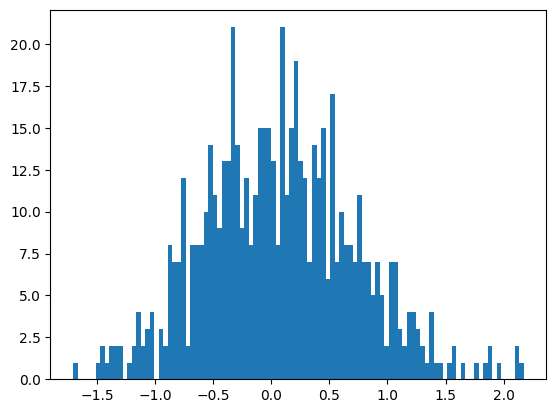

-32.538803 3990.1838 0.18331449 0.63047475 13.889778


In [17]:
plt.hist(data[150,:], bins=100)
plt.show()
# check the data values
print(np.min(data), np.max(data), np.median(data), np.mean(data), np.std(data))

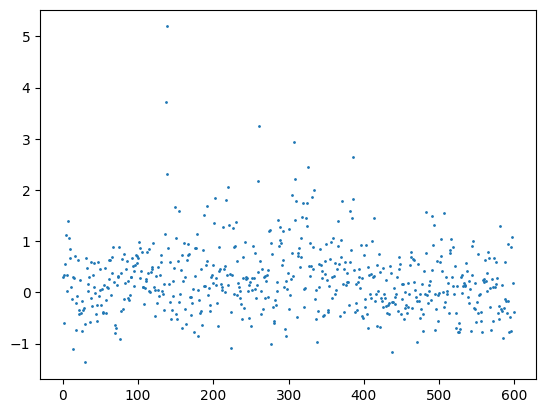

In [16]:
plt.scatter(np.arange(data.shape[0]), data[:, 150], s=1)
plt.show()
# not oversaturated

In [18]:
fits.writeto('cavia.fits', data, header=full_header, overwrite=True)

In [10]:
hdul = fits.open('ERO-Dorado/Euclid-VIS-ERO-Dorado-LSB.DR3.fits/Euclid-VIS-ERO-Dorado-LSB.v3.fits')
hdul.info()

full_data = hdul[0].data
full_header = hdul[0].header

hdul.close()

Filename: ERO-Dorado/Euclid-VIS-ERO-Dorado-LSB.DR3.fits/Euclid-VIS-ERO-Dorado-LSB.v3.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     179   (36000, 36000)   float32   


In [11]:
full_header

SIMPLE  =                    T / This is a FITS file                            
BITPIX  =                  -32 / Bits per pixel                                 
NAXIS   =                    2 /                                                
NAXIS1  =                36000 / NUMBER OF ELEMENTS ALONG THIS AXIS             
NAXIS2  =                36000 / NUMBER OF ELEMENTS ALONG THIS AXIS             
EXTEND  =                    T / This file may contain FITS extensions          
EQUINOX =        2000.00000000 / Mean equinox                                   
RADESYS = 'ICRS    '           / Astrometric system                             
CTYPE1  = 'RA---TAN'           / WCS projection type for this axis              
CUNIT1  = 'deg     '           / Axis unit                                      
CRVAL1  =   6.401433700000E+01 / World coordinate on this axis                  
CRPIX1  =   1.800050000000E+04 / Reference pixel on this axis                   
CD1_1   =  -2.777777777778E-

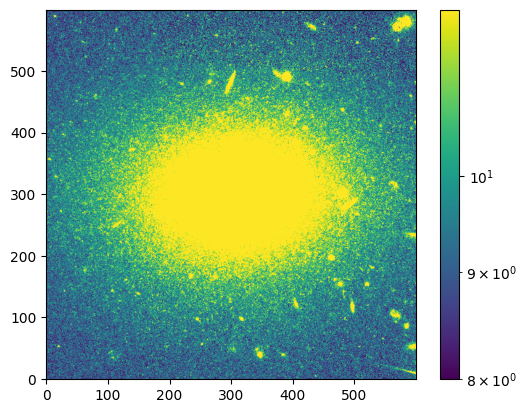

In [19]:
coorx, coory = 27662, 20615
size = 300

data2 = full_data[coory-size:coory+size, coorx-size:coorx+size]
data2field = full_data[coory-size*2:coory+size*2, coorx-size*2:coorx+size*2]
data2field[coory-size:coory+size, coorx-size:coorx+size] = np.nan

plt.imshow(data2, origin='lower', norm='log', vmin=8, vmax=12)
plt.colorbar()
plt.show()

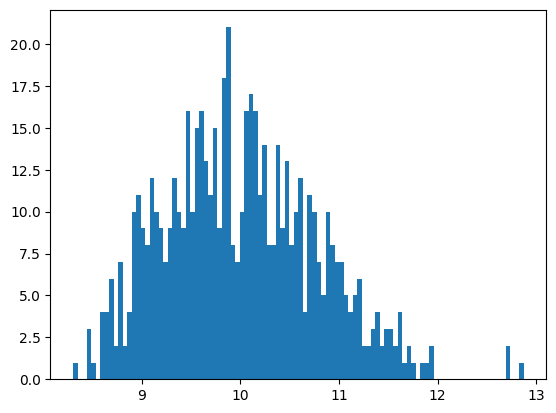

5.399539 3693.7542 9.933117 10.848693 13.812262


In [13]:
plt.hist(data2[150,:], bins=100)
plt.show()
# check the data values
print(np.nanmin(data2), np.nanmax(data2), np.nanmedian(data2), np.nanmean(data2), np.nanstd(data2))

(600, 600)
[[571 571]]


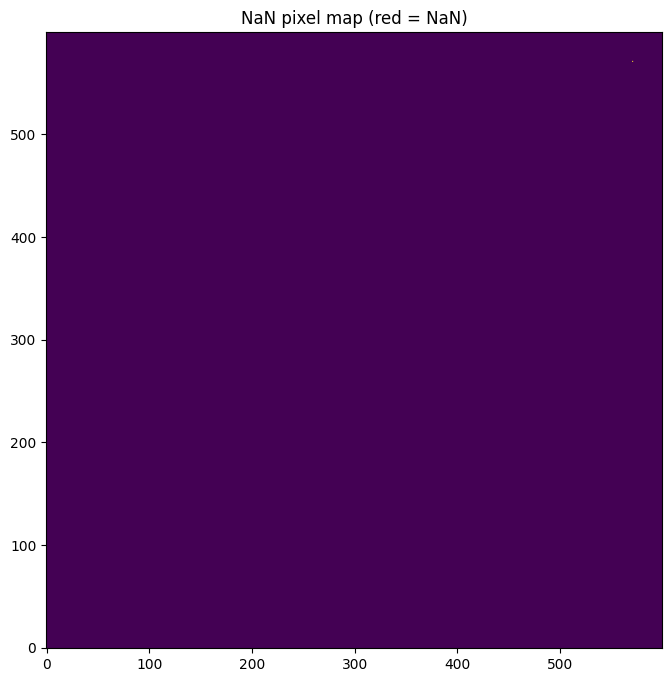

In [14]:
print(np.shape(data2))
print(np.argwhere(np.isnan(data2)))
fig = plt.figure(figsize=(8, 8))
plt.imshow(np.isnan(data2), origin='lower')
plt.title("NaN pixel map (red = NaN)")
plt.show()

In [16]:
data2_nn = np.nan_to_num(data2, nan=np.nanmedian(data2))

In [17]:
print(np.argwhere(data2_nn == np.min(data2_nn)))
print(data2_nn[571,571])

[[588 466]]
9.933117


In [20]:
fits.writeto('caviaLSB/cavia_field.fits', data2field, header=full_header, overwrite=True)

In [ ]:
fits.writeto('caviaLSB/flt/cavia.fits', data2_nn, header=full_header, overwrite=True)

In [34]:
hdul = fits.open('ERO-Dorado/Euclid-VIS-Mask-ERO-Dorado-LSB.DR3.fits/Euclid-VIS-Mask-ERO-Dorado-LSB.v3.fits')
hdul.info()

Filename: ERO-Dorado/Euclid-VIS-Mask-ERO-Dorado-LSB.DR3.fits/Euclid-VIS-Mask-ERO-Dorado-LSB.v3.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      58   (36000, 36000)   float32   


In [35]:
full_data = hdul[0].data
full_header = hdul[0].header

hdul.close()

In [36]:
full_header

SIMPLE  =                    T / This is a FITS file                            
BITPIX  =                  -32 /                                                
NAXIS   =                    2 /                                                
NAXIS1  =                36000 / NUMBER OF ELEMENTS ALONG THIS AXIS             
NAXIS2  =                36000 / NUMBER OF ELEMENTS ALONG THIS AXIS             
EXTEND  =                    T / This file may contain FITS extensions          
EQUINOX =        2000.00000000 / Mean equinox                                   
RADESYS = 'ICRS    '           / Astrometric system                             
CTYPE1  = 'RA---TAN'           / WCS projection type for this axis              
CUNIT1  = 'deg     '           / Axis unit                                      
CRVAL1  =   6.401433700000E+01 / World coordinate on this axis                  
CRPIX1  =   1.800050000000E+04 / Reference pixel on this axis                   
CD1_1   =  -2.777777777778E-

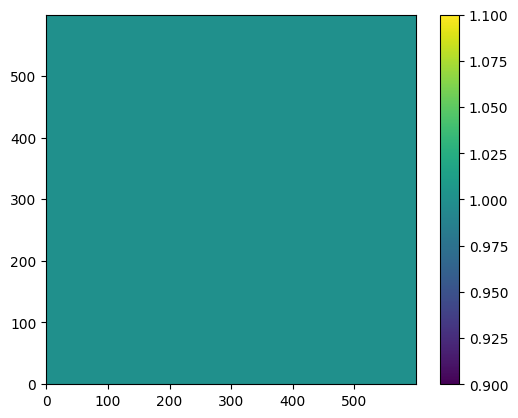

In [ ]:
datam = full_data[coory-size:coory+size, coorx-size:coorx+size]

plt.imshow(datam, origin='lower')#, norm='log', vmin=8, vmax=12)
plt.colorbar()
plt.show()

In [48]:
print(np.min(datam), np.max(datam))

# so the mask is useless here
# plt.hist(datam)
# plt.show()

1.0 1.0


# Dorado dwarfs 

In [8]:
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS
from astropy.nddata import Cutout2D
from astropy.io import fits
from astropy import units as u
import matplotlib.pyplot as plt
import numpy as np

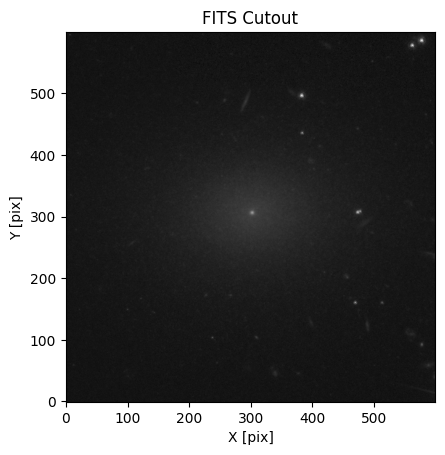

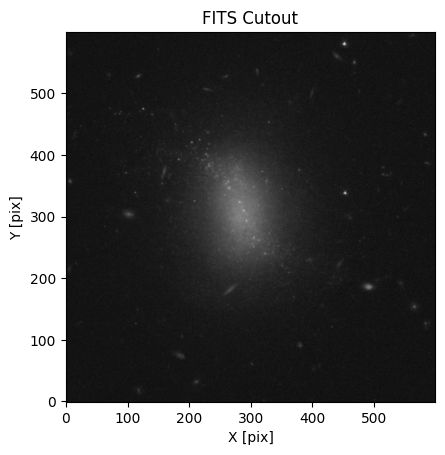

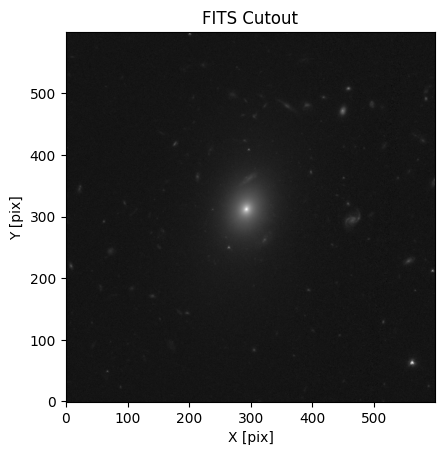

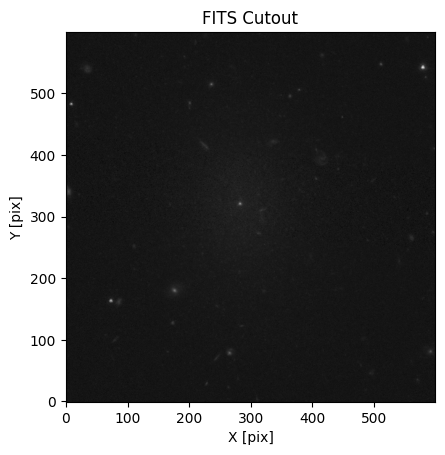

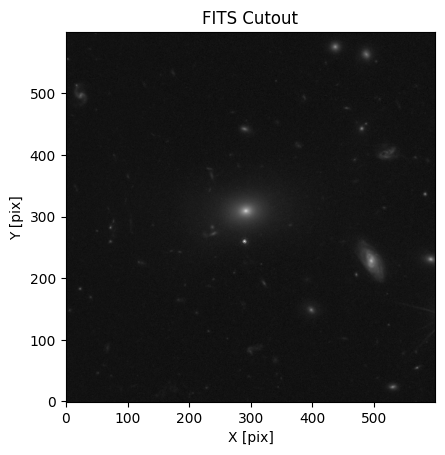

In [30]:
coor_list = [('04 14 09.024', '-55 42 27.23'), # cavia?
              ('04 18 07.156', '-55 55 49.85'),
              ('04 15 31.211', '-55 59 26.84'),
              ('04 18 04.308', '-55 45 30.73'),  # pretty!
              ('04 17 48.841', '-55 28 17.96')]
cutout_sizes = [600, 600, 600, 600, 600]
names = ['A', 'B', 'C', 'D', 'E']
hdul= fits.open('ERO-Dorado/Euclid-VIS-ERO-Dorado-LSB.v3.fits')
full_data = hdul[0].data
full_header = hdul[0].header
wcs = WCS(full_header)
for coor, cutout_size, name in zip(coor_list, cutout_sizes, names):
    ra_center, dec_center = coor
    position = SkyCoord(ra_center, dec_center, unit=(u.hourangle, u.deg), frame='icrs')
    cutout = Cutout2D(full_data, position, (cutout_size, cutout_size), wcs=wcs, copy=True)
    new_header = full_header.copy()
    new_header.update(cutout.wcs.to_header())
    hdu_cutout = fits.PrimaryHDU(data=cutout.data, header=new_header)
    hdu_cutout.writeto("dwarfs/{}/flt/dwarf_{}.fits".format(name, name), overwrite=True)

    fieldcutout = Cutout2D(full_data, position, (cutout_size*2, cutout_size*2), wcs=wcs, copy=True)
    new_header_field = full_header.copy()
    new_header_field.update(fieldcutout.wcs.to_header())

    hdu_fieldcutout = fits.PrimaryHDU(data=fieldcutout.data, header=new_header_field)
    hdu_fieldcutout.data[cutout_size//2:cutout_size*3//2, cutout_size//2:cutout_size*3//2] = np.nan ## FIXXXX
    hdu_fieldcutout.writeto("dwarfs/{}/field_dwarf_{}.fits".format(name, name), overwrite=True)
    

    plt.figure()
    plt.imshow(cutout.data, origin='lower', cmap='gray', norm='log')
    plt.xlabel('X [pix]')
    plt.ylabel('Y [pix]')
    plt.title('FITS Cutout')
    plt.show()

hdul.close()

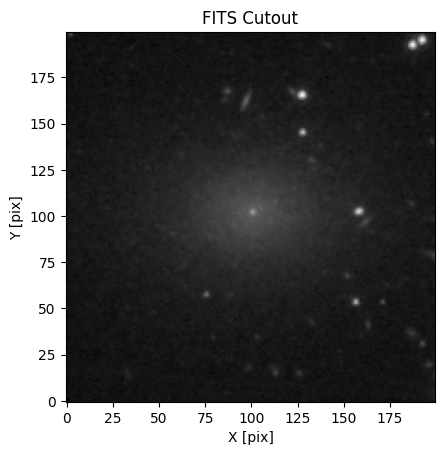

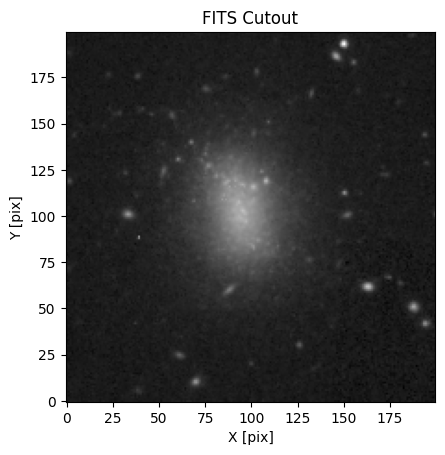

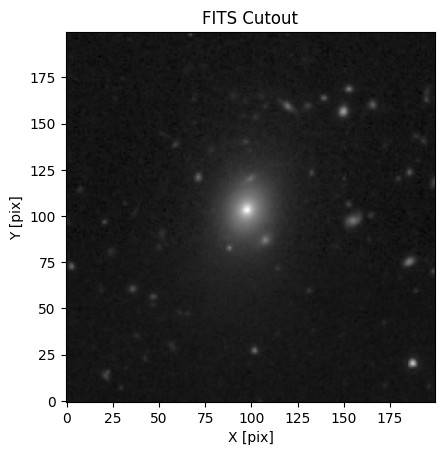

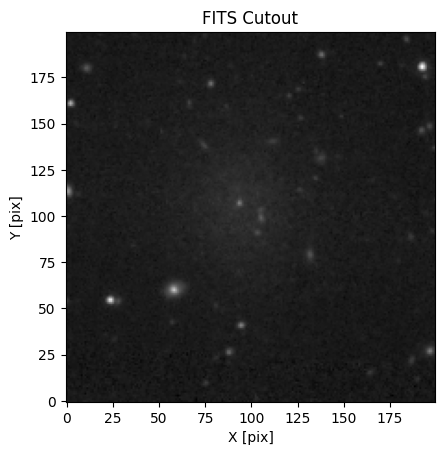

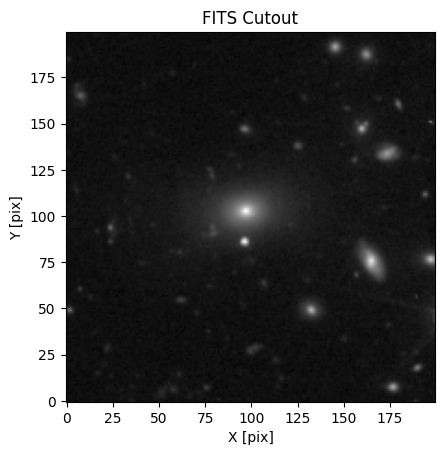

In [34]:
# dwarfs H-band
import os

coor_list = [('04 14 09.024', '-55 42 27.23'), # cavia?
              ('04 18 07.156', '-55 55 49.85'),
              ('04 15 31.211', '-55 59 26.84'),
              ('04 18 04.308', '-55 45 30.73'),  # pretty!
              ('04 17 48.841', '-55 28 17.96')]
cutout_sizes = np.array([600, 600, 600, 600, 600])//3
names = ['A', 'B', 'C', 'D', 'E']
hdul= fits.open('ERO-Dorado/Euclid-NISP-H-ERO-Dorado-LSB.v3.fits')
full_data = hdul[0].data
full_header = hdul[0].header
wcs = WCS(full_header)
for coor, cutout_size, name in zip(coor_list, cutout_sizes, names):
    ra_center, dec_center = coor
    position = SkyCoord(ra_center, dec_center, unit=(u.hourangle, u.deg), frame='icrs')
    cutout = Cutout2D(full_data, position, (cutout_size, cutout_size), wcs=wcs, copy=True)
    new_header = full_header.copy()
    new_header.update(cutout.wcs.to_header())
    hdu_cutout = fits.PrimaryHDU(data=cutout.data, header=new_header)
    try:
        os.makedirs("dwarfsH/{}/flt".format(name))
    except FileExistsError:
        # directory already exists
        pass
    hdu_cutout.writeto("dwarfsH/{}/flt/dwarf_{}.fits".format(name, name), overwrite=True)

    fieldcutout = Cutout2D(full_data, position, (cutout_size*2, cutout_size*2), wcs=wcs, copy=True)
    new_header_field = full_header.copy()
    new_header_field.update(fieldcutout.wcs.to_header())

    hdu_fieldcutout = fits.PrimaryHDU(data=fieldcutout.data, header=new_header_field)
    hdu_fieldcutout.data[cutout_size//2:cutout_size*3//2, cutout_size//2:cutout_size*3//2] = np.nan ## FIXXXX
    hdu_fieldcutout.writeto("dwarfsH/{}/field_dwarf_{}.fits".format(name, name), overwrite=True)
    

    plt.figure()
    plt.imshow(cutout.data, origin='lower', cmap='gray', norm='log')
    plt.xlabel('X [pix]')
    plt.ylabel('Y [pix]')
    plt.title('FITS Cutout')
    plt.show()

hdul.close()

# EUC MER catalogues

In [5]:
import numpy as np
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.wcs import WCS 
from astropy.table import Table
from astropy import units as u


0.004166666666666667


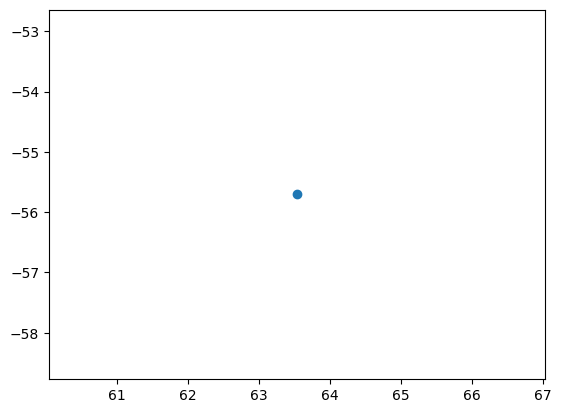

GAL_EBV,GAL_EBV_ERR
mag,mag
float32,float32
0.01666538,0.00062109233


In [ ]:
# coorRADEC = [
#     (63.5376000, -55.7075639),	#	EBV (mag) = 0.015011813 +- 0.00036210485
#     (64.5298167, -55.9305139),    #	EBV (mag) = 0.028110811 +- 0.0014827326
#     (63.8800458, -55.9907889),	#	EBV (mag) = 0.021470912 +- 0.0012913165
#     (64.4535042, -55.4716556)]	#	EBV (mag) = 0.016753558 +- 0.00084380305

# for RA, DEC in zip(coorRADEC[0,:], coorRADEC[1,:]):

import warnings
warnings.filterwarnings('ignore', category=u.UnitsWarning)

path = 'EUC_MER_FINAL-CAT_TILES/EUC_MER_FINAL-CAT_TILE102014760-E3917E_20250728T131717.666669Z_00.00.fits/EUC_MER_FINAL-CAT_TILE102014760-E3917E_20250728T131717.666669Z_00.00.fits'
table = Table.read(path, hdu=1)

0.004166666666666667


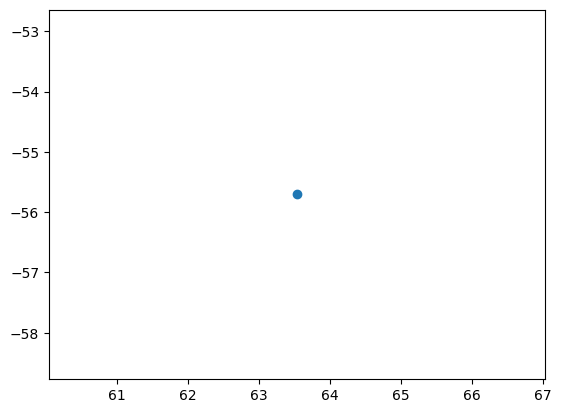

GAL_EBV,GAL_EBV_ERR
mag,mag
float32,float32
0.01666538,0.00062109233


In [5]:
RA_A, DEC_A = 63.5376000, -55.7075639
size = (15*u.arcsec).to(u.degree).value
print(size)
possids = []

for id, ra, dec in zip(table['OBJECT_ID'], table['RIGHT_ASCENSION'], table['DECLINATION']):
    if ra > RA_A-size and ra < RA_A+size and dec > DEC_A-size and dec < DEC_A+size:
        plt.scatter(ra, dec)
        possids.append(id)
plt.show()

table[table['OBJECT_ID']==possids]['GAL_EBV', 'GAL_EBV_ERR']

In [6]:
table[table['OBJECT_ID']==possids]

OBJECT_ID,RIGHT_ASCENSION,DECLINATION,RIGHT_ASCENSION_PSF_FITTING,DECLINATION_PSF_FITTING,TILE_INDEX,SEGMENTATION_MAP_ID,VIS_DET,FLUX_VIS_1FWHM_APER,FLUX_VIS_2FWHM_APER,FLUX_VIS_3FWHM_APER,FLUX_VIS_4FWHM_APER,FLUX_Y_1FWHM_APER,FLUX_Y_2FWHM_APER,FLUX_Y_3FWHM_APER,FLUX_Y_4FWHM_APER,FLUX_J_1FWHM_APER,FLUX_J_2FWHM_APER,FLUX_J_3FWHM_APER,FLUX_J_4FWHM_APER,FLUX_H_1FWHM_APER,FLUX_H_2FWHM_APER,FLUX_H_3FWHM_APER,FLUX_H_4FWHM_APER,FLUX_NIR_STACK_1FWHM_APER,FLUX_NIR_STACK_2FWHM_APER,FLUX_NIR_STACK_3FWHM_APER,FLUX_NIR_STACK_4FWHM_APER,FLUX_U_EXT_DECAM_1FWHM_APER,FLUX_U_EXT_DECAM_2FWHM_APER,FLUX_U_EXT_DECAM_3FWHM_APER,FLUX_U_EXT_DECAM_4FWHM_APER,FLUX_G_EXT_DECAM_1FWHM_APER,FLUX_G_EXT_DECAM_2FWHM_APER,FLUX_G_EXT_DECAM_3FWHM_APER,FLUX_G_EXT_DECAM_4FWHM_APER,FLUX_R_EXT_DECAM_1FWHM_APER,FLUX_R_EXT_DECAM_2FWHM_APER,FLUX_R_EXT_DECAM_3FWHM_APER,FLUX_R_EXT_DECAM_4FWHM_APER,FLUX_I_EXT_DECAM_1FWHM_APER,FLUX_I_EXT_DECAM_2FWHM_APER,FLUX_I_EXT_DECAM_3FWHM_APER,FLUX_I_EXT_DECAM_4FWHM_APER,FLUX_Z_EXT_DECAM_1FWHM_APER,FLUX_Z_EXT_DECAM_2FWHM_APER,FLUX_Z_EXT_DECAM_3FWHM_APER,FLUX_Z_EXT_DECAM_4FWHM_APER,FLUX_U_EXT_LSST_1FWHM_APER,FLUX_U_EXT_LSST_2FWHM_APER,FLUX_U_EXT_LSST_3FWHM_APER,FLUX_U_EXT_LSST_4FWHM_APER,FLUX_G_EXT_LSST_1FWHM_APER,FLUX_G_EXT_LSST_2FWHM_APER,FLUX_G_EXT_LSST_3FWHM_APER,FLUX_G_EXT_LSST_4FWHM_APER,FLUX_R_EXT_LSST_1FWHM_APER,FLUX_R_EXT_LSST_2FWHM_APER,FLUX_R_EXT_LSST_3FWHM_APER,FLUX_R_EXT_LSST_4FWHM_APER,FLUX_I_EXT_LSST_1FWHM_APER,FLUX_I_EXT_LSST_2FWHM_APER,FLUX_I_EXT_LSST_3FWHM_APER,FLUX_I_EXT_LSST_4FWHM_APER,FLUX_Z_EXT_LSST_1FWHM_APER,FLUX_Z_EXT_LSST_2FWHM_APER,FLUX_Z_EXT_LSST_3FWHM_APER,FLUX_Z_EXT_LSST_4FWHM_APER,FLUX_U_EXT_MEGACAM_1FWHM_APER,FLUX_U_EXT_MEGACAM_2FWHM_APER,FLUX_U_EXT_MEGACAM_3FWHM_APER,FLUX_U_EXT_MEGACAM_4FWHM_APER,FLUX_R_EXT_MEGACAM_1FWHM_APER,FLUX_R_EXT_MEGACAM_2FWHM_APER,FLUX_R_EXT_MEGACAM_3FWHM_APER,FLUX_R_EXT_MEGACAM_4FWHM_APER,FLUX_G_EXT_JPCAM_1FWHM_APER,FLUX_G_EXT_JPCAM_2FWHM_APER,FLUX_G_EXT_JPCAM_3FWHM_APER,FLUX_G_EXT_JPCAM_4FWHM_APER,FLUX_I_EXT_PANSTARRS_1FWHM_APER,FLUX_I_EXT_PANSTARRS_2FWHM_APER,FLUX_I_EXT_PANSTARRS_3FWHM_APER,FLUX_I_EXT_PANSTARRS_4FWHM_APER,FLUX_Z_EXT_PANSTARRS_1FWHM_APER,FLUX_Z_EXT_PANSTARRS_2FWHM_APER,FLUX_Z_EXT_PANSTARRS_3FWHM_APER,FLUX_Z_EXT_PANSTARRS_4FWHM_APER,FLUX_G_EXT_HSC_1FWHM_APER,FLUX_G_EXT_HSC_2FWHM_APER,FLUX_G_EXT_HSC_3FWHM_APER,FLUX_G_EXT_HSC_4FWHM_APER,FLUX_Z_EXT_HSC_1FWHM_APER,FLUX_Z_EXT_HSC_2FWHM_APER,FLUX_Z_EXT_HSC_3FWHM_APER,FLUX_Z_EXT_HSC_4FWHM_APER,FLUXERR_VIS_1FWHM_APER,FLUXERR_VIS_2FWHM_APER,FLUXERR_VIS_3FWHM_APER,FLUXERR_VIS_4FWHM_APER,FLUXERR_Y_1FWHM_APER,FLUXERR_Y_2FWHM_APER,FLUXERR_Y_3FWHM_APER,FLUXERR_Y_4FWHM_APER,FLUXERR_J_1FWHM_APER,FLUXERR_J_2FWHM_APER,FLUXERR_J_3FWHM_APER,FLUXERR_J_4FWHM_APER,FLUXERR_H_1FWHM_APER,FLUXERR_H_2FWHM_APER,FLUXERR_H_3FWHM_APER,FLUXERR_H_4FWHM_APER,FLUXERR_NIR_STACK_1FWHM_APER,FLUXERR_NIR_STACK_2FWHM_APER,FLUXERR_NIR_STACK_3FWHM_APER,FLUXERR_NIR_STACK_4FWHM_APER,FLUXERR_U_EXT_DECAM_1FWHM_APER,FLUXERR_U_EXT_DECAM_2FWHM_APER,FLUXERR_U_EXT_DECAM_3FWHM_APER,FLUXERR_U_EXT_DECAM_4FWHM_APER,FLUXERR_G_EXT_DECAM_1FWHM_APER,FLUXERR_G_EXT_DECAM_2FWHM_APER,FLUXERR_G_EXT_DECAM_3FWHM_APER,FLUXERR_G_EXT_DECAM_4FWHM_APER,FLUXERR_R_EXT_DECAM_1FWHM_APER,FLUXERR_R_EXT_DECAM_2FWHM_APER,FLUXERR_R_EXT_DECAM_3FWHM_APER,FLUXERR_R_EXT_DECAM_4FWHM_APER,FLUXERR_I_EXT_DECAM_1FWHM_APER,FLUXERR_I_EXT_DECAM_2FWHM_APER,FLUXERR_I_EXT_DECAM_3FWHM_APER,FLUXERR_I_EXT_DECAM_4FWHM_APER,FLUXERR_Z_EXT_DECAM_1FWHM_APER,FLUXERR_Z_EXT_DECAM_2FWHM_APER,FLUXERR_Z_EXT_DECAM_3FWHM_APER,FLUXERR_Z_EXT_DECAM_4FWHM_APER,FLUXERR_U_EXT_LSST_1FWHM_APER,FLUXERR_U_EXT_LSST_2FWHM_APER,FLUXERR_U_EXT_LSST_3FWHM_APER,FLUXERR_U_EXT_LSST_4FWHM_APER,FLUXERR_G_EXT_LSST_1FWHM_APER,FLUXERR_G_EXT_LSST_2FWHM_APER,FLUXERR_G_EXT_LSST_3FWHM_APER,FLUXERR_G_EXT_LSST_4FWHM_APER,FLUXERR_R_EXT_LSST_1FWHM_APER,FLUXERR_R_EXT_LSST_2FWHM_APER,FLUXERR_R_EXT_LSST_3FWHM_APER,FLUXERR_R_EXT_LSST_4FWHM_APER,FLUXERR_I_EXT_LSST_1FWHM_APER,FLUXERR_I_EXT_LSST_2FWHM_APER,FLUXERR_I_EXT_LSST_3FWHM_APER,FLUXERR_I_EXT_LSST_4FWHM_

In [ ]:
# to show WRONG indexing
# table['OBJECT_ID'==possids]

OBJECT_ID,RIGHT_ASCENSION,DECLINATION,RIGHT_ASCENSION_PSF_FITTING,DECLINATION_PSF_FITTING,TILE_INDEX,SEGMENTATION_MAP_ID,VIS_DET,FLUX_VIS_1FWHM_APER,FLUX_VIS_2FWHM_APER,FLUX_VIS_3FWHM_APER,FLUX_VIS_4FWHM_APER,FLUX_Y_1FWHM_APER,FLUX_Y_2FWHM_APER,FLUX_Y_3FWHM_APER,FLUX_Y_4FWHM_APER,FLUX_J_1FWHM_APER,FLUX_J_2FWHM_APER,FLUX_J_3FWHM_APER,FLUX_J_4FWHM_APER,FLUX_H_1FWHM_APER,FLUX_H_2FWHM_APER,FLUX_H_3FWHM_APER,FLUX_H_4FWHM_APER,FLUX_NIR_STACK_1FWHM_APER,FLUX_NIR_STACK_2FWHM_APER,FLUX_NIR_STACK_3FWHM_APER,FLUX_NIR_STACK_4FWHM_APER,FLUX_U_EXT_DECAM_1FWHM_APER,FLUX_U_EXT_DECAM_2FWHM_APER,FLUX_U_EXT_DECAM_3FWHM_APER,FLUX_U_EXT_DECAM_4FWHM_APER,FLUX_G_EXT_DECAM_1FWHM_APER,FLUX_G_EXT_DECAM_2FWHM_APER,FLUX_G_EXT_DECAM_3FWHM_APER,FLUX_G_EXT_DECAM_4FWHM_APER,FLUX_R_EXT_DECAM_1FWHM_APER,FLUX_R_EXT_DECAM_2FWHM_APER,FLUX_R_EXT_DECAM_3FWHM_APER,FLUX_R_EXT_DECAM_4FWHM_APER,FLUX_I_EXT_DECAM_1FWHM_APER,FLUX_I_EXT_DECAM_2FWHM_APER,FLUX_I_EXT_DECAM_3FWHM_APER,FLUX_I_EXT_DECAM_4FWHM_APER,FLUX_Z_EXT_DECAM_1FWHM_APER,FLUX_Z_EXT_DECAM_2FWHM_APER,FLUX_Z_EXT_DECAM_3FWHM_APER,FLUX_Z_EXT_DECAM_4FWHM_APER,FLUX_U_EXT_LSST_1FWHM_APER,FLUX_U_EXT_LSST_2FWHM_APER,FLUX_U_EXT_LSST_3FWHM_APER,FLUX_U_EXT_LSST_4FWHM_APER,FLUX_G_EXT_LSST_1FWHM_APER,FLUX_G_EXT_LSST_2FWHM_APER,FLUX_G_EXT_LSST_3FWHM_APER,FLUX_G_EXT_LSST_4FWHM_APER,FLUX_R_EXT_LSST_1FWHM_APER,FLUX_R_EXT_LSST_2FWHM_APER,FLUX_R_EXT_LSST_3FWHM_APER,FLUX_R_EXT_LSST_4FWHM_APER,FLUX_I_EXT_LSST_1FWHM_APER,FLUX_I_EXT_LSST_2FWHM_APER,FLUX_I_EXT_LSST_3FWHM_APER,FLUX_I_EXT_LSST_4FWHM_APER,FLUX_Z_EXT_LSST_1FWHM_APER,FLUX_Z_EXT_LSST_2FWHM_APER,FLUX_Z_EXT_LSST_3FWHM_APER,FLUX_Z_EXT_LSST_4FWHM_APER,FLUX_U_EXT_MEGACAM_1FWHM_APER,FLUX_U_EXT_MEGACAM_2FWHM_APER,FLUX_U_EXT_MEGACAM_3FWHM_APER,FLUX_U_EXT_MEGACAM_4FWHM_APER,FLUX_R_EXT_MEGACAM_1FWHM_APER,FLUX_R_EXT_MEGACAM_2FWHM_APER,FLUX_R_EXT_MEGACAM_3FWHM_APER,FLUX_R_EXT_MEGACAM_4FWHM_APER,FLUX_G_EXT_JPCAM_1FWHM_APER,FLUX_G_EXT_JPCAM_2FWHM_APER,FLUX_G_EXT_JPCAM_3FWHM_APER,FLUX_G_EXT_JPCAM_4FWHM_APER,FLUX_I_EXT_PANSTARRS_1FWHM_APER,FLUX_I_EXT_PANSTARRS_2FWHM_APER,FLUX_I_EXT_PANSTARRS_3FWHM_APER,FLUX_I_EXT_PANSTARRS_4FWHM_APER,FLUX_Z_EXT_PANSTARRS_1FWHM_APER,FLUX_Z_EXT_PANSTARRS_2FWHM_APER,FLUX_Z_EXT_PANSTARRS_3FWHM_APER,FLUX_Z_EXT_PANSTARRS_4FWHM_APER,FLUX_G_EXT_HSC_1FWHM_APER,FLUX_G_EXT_HSC_2FWHM_APER,FLUX_G_EXT_HSC_3FWHM_APER,FLUX_G_EXT_HSC_4FWHM_APER,FLUX_Z_EXT_HSC_1FWHM_APER,FLUX_Z_EXT_HSC_2FWHM_APER,FLUX_Z_EXT_HSC_3FWHM_APER,FLUX_Z_EXT_HSC_4FWHM_APER,FLUXERR_VIS_1FWHM_APER,FLUXERR_VIS_2FWHM_APER,FLUXERR_VIS_3FWHM_APER,FLUXERR_VIS_4FWHM_APER,FLUXERR_Y_1FWHM_APER,FLUXERR_Y_2FWHM_APER,FLUXERR_Y_3FWHM_APER,FLUXERR_Y_4FWHM_APER,FLUXERR_J_1FWHM_APER,FLUXERR_J_2FWHM_APER,FLUXERR_J_3FWHM_APER,FLUXERR_J_4FWHM_APER,FLUXERR_H_1FWHM_APER,FLUXERR_H_2FWHM_APER,FLUXERR_H_3FWHM_APER,FLUXERR_H_4FWHM_APER,FLUXERR_NIR_STACK_1FWHM_APER,FLUXERR_NIR_STACK_2FWHM_APER,FLUXERR_NIR_STACK_3FWHM_APER,FLUXERR_NIR_STACK_4FWHM_APER,FLUXERR_U_EXT_DECAM_1FWHM_APER,FLUXERR_U_EXT_DECAM_2FWHM_APER,FLUXERR_U_EXT_DECAM_3FWHM_APER,FLUXERR_U_EXT_DECAM_4FWHM_APER,FLUXERR_G_EXT_DECAM_1FWHM_APER,FLUXERR_G_EXT_DECAM_2FWHM_APER,FLUXERR_G_EXT_DECAM_3FWHM_APER,FLUXERR_G_EXT_DECAM_4FWHM_APER,FLUXERR_R_EXT_DECAM_1FWHM_APER,FLUXERR_R_EXT_DECAM_2FWHM_APER,FLUXERR_R_EXT_DECAM_3FWHM_APER,FLUXERR_R_EXT_DECAM_4FWHM_APER,FLUXERR_I_EXT_DECAM_1FWHM_APER,FLUXERR_I_EXT_DECAM_2FWHM_APER,FLUXERR_I_EXT_DECAM_3FWHM_APER,FLUXERR_I_EXT_DECAM_4FWHM_APER,FLUXERR_Z_EXT_DECAM_1FWHM_APER,FLUXERR_Z_EXT_DECAM_2FWHM_APER,FLUXERR_Z_EXT_DECAM_3FWHM_APER,FLUXERR_Z_EXT_DECAM_4FWHM_APER,FLUXERR_U_EXT_LSST_1FWHM_APER,FLUXERR_U_EXT_LSST_2FWHM_APER,FLUXERR_U_EXT_LSST_3FWHM_APER,FLUXERR_U_EXT_LSST_4FWHM_APER,FLUXERR_G_EXT_LSST_1FWHM_APER,FLUXERR_G_EXT_LSST_2FWHM_APER,FLUXERR_G_EXT_LSST_3FWHM_APER,FLUXERR_G_EXT_LSST_4FWHM_APER,FLUXERR_R_EXT_LSST_1FWHM_APER,FLUXERR_R_EXT_LSST_2FWHM_APER,FLUXERR_R_EXT_LSST_3FWHM_APER,FLUXERR_R_EXT_LSST_4FWHM_APER,FLUXERR_I_EXT_LSST_1FWHM_APER,FLUXERR_I_EXT_LSST_2FWHM_APER,FLUXERR_I_EXT_LSST_3FWHM_APER,FLUXERR_I_EXT_LSST_4FWHM_

## Fornax cluster 

In [13]:
FCCTable = np.array((('FCC144', 53.751045, -35.322303),
('FCC146', 53.79833, -35.32306),
('FCC147', 53.81916, -35.22627),
('FCC148', 53.82003, -35.26563),
('FCC156', 53.92809, -35.33808),
('FCC167', 54.11488, -34.97603),
('FCC168', 54.116554, -35.210704),
('FCC181', 54.221908, -34.938466),
('FCC184', 54.23764,-35.50653)))



FCCMorevalues = np.array(((4.72,0.121,0.036,30.14,0.11),
(4.65,0.193,0.034,29.74,0.14),
(20.01,0.786,0.001,30.83,0.07),
(27.61, 0.624,0.008, 30.49,0.05),
(8.63,0.289,0.013, 30.42,np.nan),
(31.25,0.885,0.0,31.03,0.07),
(5.28,0.213,0.034,30.38,0.04), 
(8.35, 0.383,0.009,30.35,0.04),
(20.78,0.886,0.0,31.1,0.04)))




FCCTable = Table(FCCTable, names=('Name', 'ra', 'dec'))
FCCMorevalues = Table(FCCMorevalues, names=('Re', 'IE-HE', 'IE-HE_ERR', 'mIE', 'mIE_ERR'))
FCCTable = FCCTable | FCCMorevalues

FCCTable

Name,ra,dec,Re,IE-HE,IE-HE_ERR,mIE,mIE_ERR
str32,str32,str32,float64,float64,float64,float64,float64
FCC144,53.751045,-35.322303,4.72,0.121,0.036,30.14,0.11
FCC146,53.79833,-35.32306,4.65,0.193,0.034,29.74,0.14
FCC147,53.81916,-35.22627,20.01,0.786,0.001,30.83,0.07
FCC148,53.82003,-35.26563,27.61,0.624,0.008,30.49,0.05
FCC156,53.92809,-35.33808,8.63,0.289,0.013,30.42,nan
FCC167,54.11488,-34.97603,31.25,0.885,0.0,31.03,0.07
FCC168,54.116554,-35.210704,5.28,0.213,0.034,30.38,0.04
FCC181,54.221908,-34.938466,8.35,0.383,0.009,30.35,0.04
FCC184,54.23764,-35.50653,20.78,0.886,0.0,31.1,0.04


In [3]:
import os

In [14]:
for cutout_size, name in zip(cutout_sizes, FCCTable['Name']):
    print(name)

FCC144
FCC146
FCC147
FCC148
FCC156


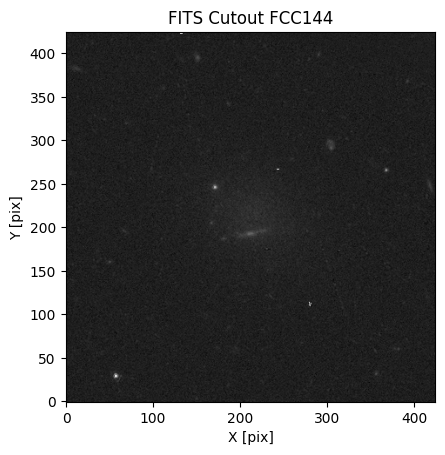

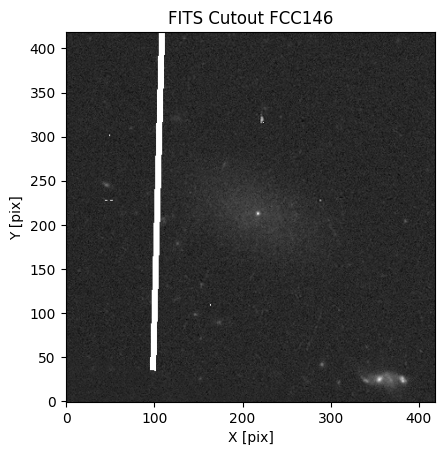

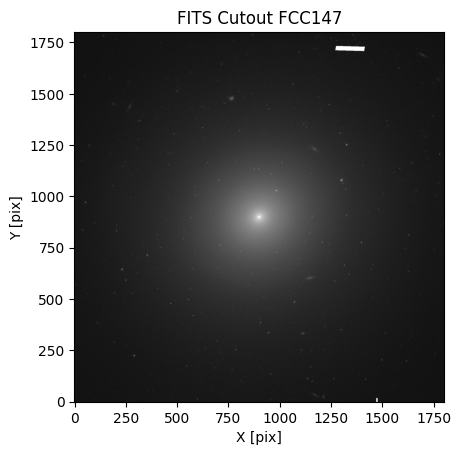

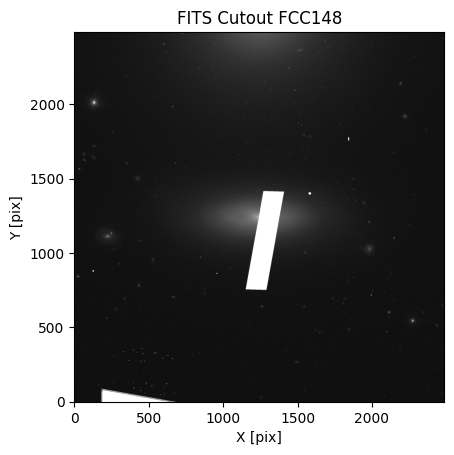

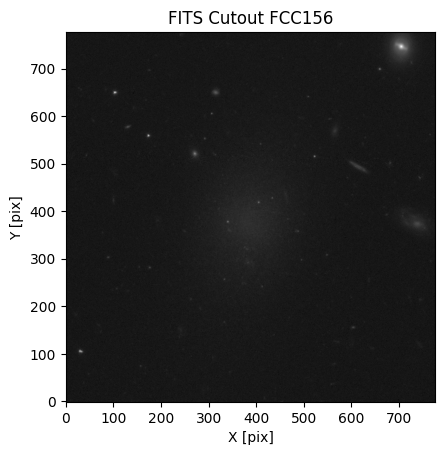

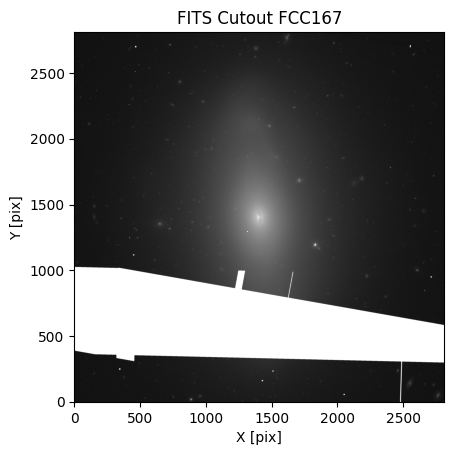

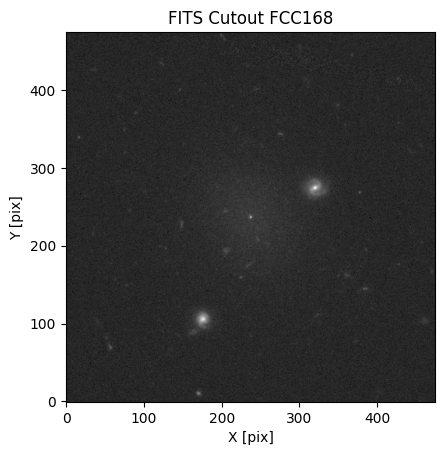

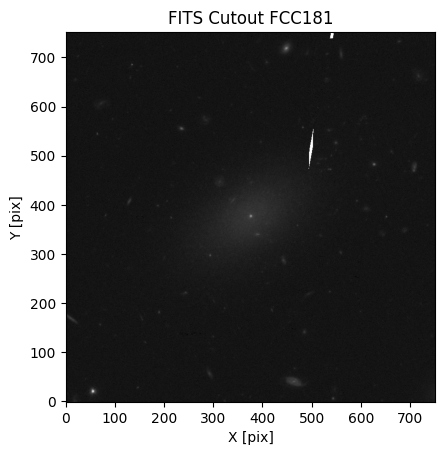

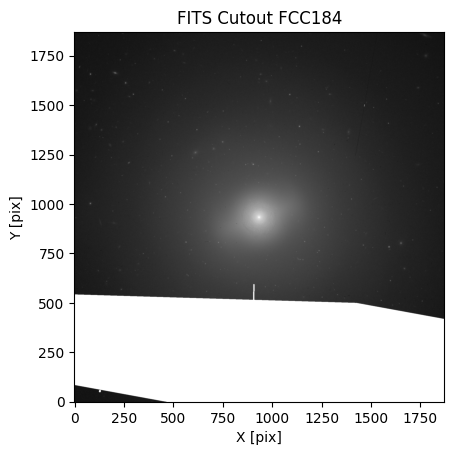

In [15]:
hdul= fits.open('ERO-Fornax/Euclid-VIS-ERO-Fornax-LSB.DR3.fits')
full_data = hdul[0].data
full_header = hdul[0].header
wcs = WCS(full_header)
hdul.close()
for name in FCCTable['Name']:
    cutout_size = round(FCCTable[FCCTable['Name']==name]['Re'].value[0]*90)
    ra_center = FCCTable[FCCTable['Name']==name]['ra']
    dec_center = FCCTable[FCCTable['Name']==name]['dec']
    position = SkyCoord(ra_center, dec_center, unit=(u.deg, u.deg), frame='icrs')
    cutout = Cutout2D(full_data, position, (cutout_size, cutout_size), wcs=wcs, copy=True)
    new_header = full_header.copy()
    new_header.update(cutout.wcs.to_header())
    hdu_cutout = fits.PrimaryHDU(data=cutout.data, header=new_header)
    try:
        os.makedirs("FornaxLSB/{}/flt".format(name))
    except FileExistsError:
        # directory already exists
        pass
    hdu_cutout.writeto("FornaxLSB/{}/flt/{}.fits".format(name, name), overwrite=True)

    fieldcutout = Cutout2D(full_data, position, (cutout_size*2, cutout_size*2), wcs=wcs, copy=True)
    new_header_field = full_header.copy()
    new_header_field.update(fieldcutout.wcs.to_header())

    hdu_fieldcutout = fits.PrimaryHDU(data=fieldcutout.data, header=new_header_field)
    hdu_fieldcutout.data[cutout_size//2:cutout_size*3//2, cutout_size//2:cutout_size*3//2] = np.nan ## FIXXXX
    hdu_fieldcutout.writeto("FornaxLSB/{}/field_{}.fits".format(name, name), overwrite=True)
    

    plt.figure()
    plt.imshow(cutout.data, origin='lower', cmap='gray', norm='log')
    plt.xlabel('X [pix]')
    plt.ylabel('Y [pix]')
    plt.title('FITS Cutout {}'.format(name))
    plt.show()



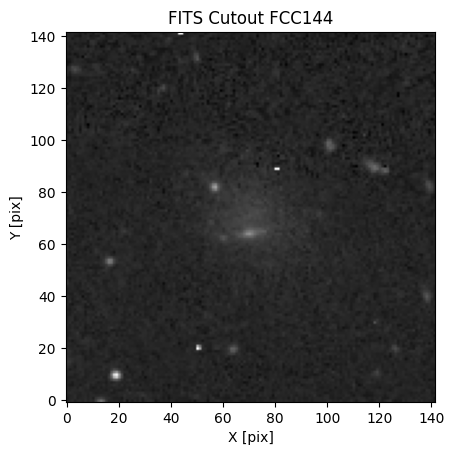

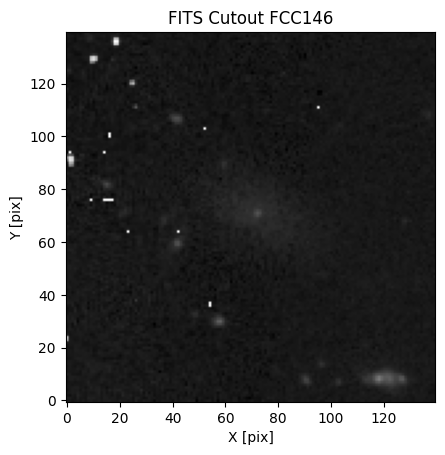

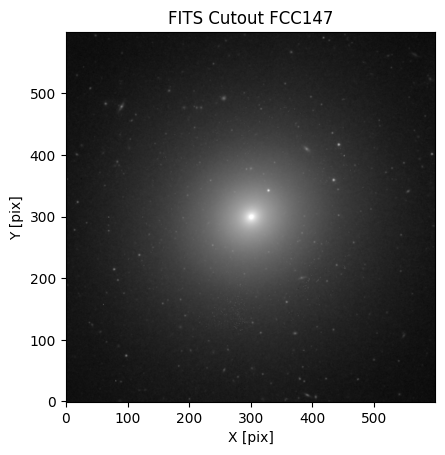

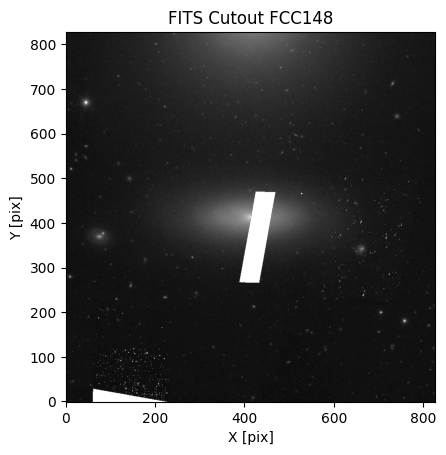

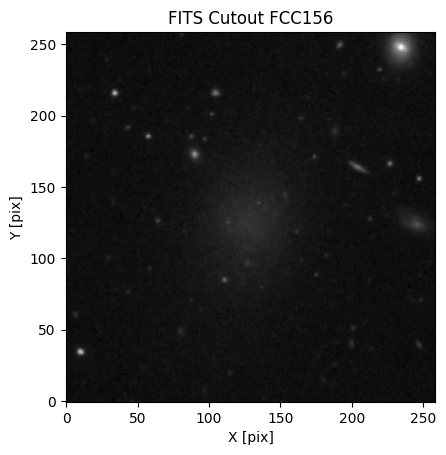

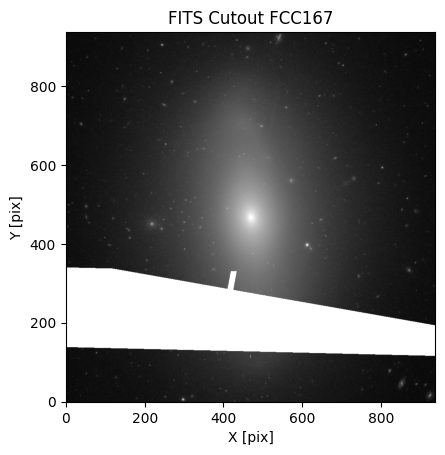

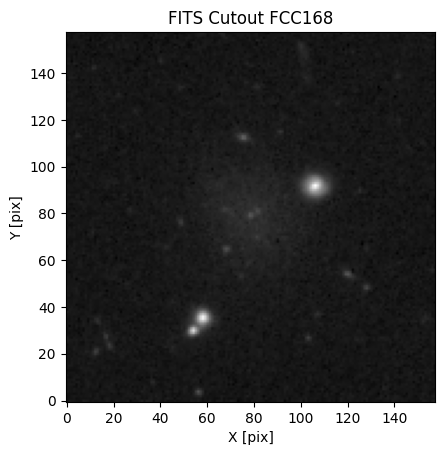

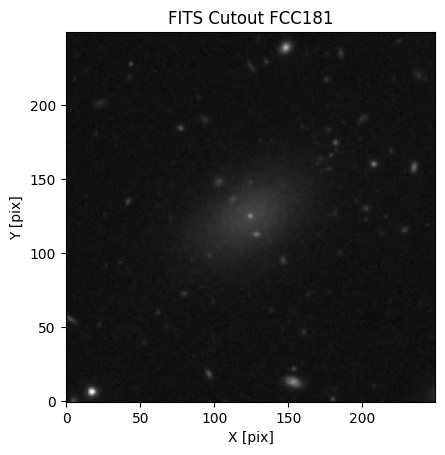

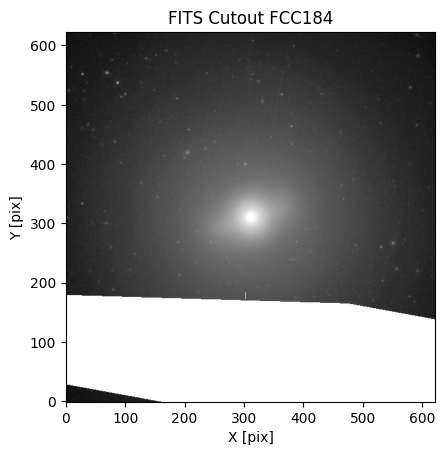

In [16]:
# now the same in the H-band

hdul= fits.open('ERO-Fornax/Euclid-NISP-H-ERO-Fornax-LSB.DR3.fits')
full_data = hdul[0].data
full_header = hdul[0].header
wcs = WCS(full_header)
hdul.close()
for name in FCCTable['Name']:
    cutout_size = round(FCCTable[FCCTable['Name']==name]['Re'].value[0]*30)
    ra_center = FCCTable[FCCTable['Name']==name]['ra']
    dec_center = FCCTable[FCCTable['Name']==name]['dec']
    position = SkyCoord(ra_center, dec_center, unit=(u.deg, u.deg), frame='icrs')
    cutout = Cutout2D(full_data, position, (cutout_size, cutout_size), wcs=wcs, copy=True)
    new_header = full_header.copy()
    new_header.update(cutout.wcs.to_header())
    hdu_cutout = fits.PrimaryHDU(data=cutout.data, header=new_header)
    try:
        os.makedirs("FornaxH/{}/flt".format(name))
    except FileExistsError:
        # directory already exists
        pass
    hdu_cutout.writeto("FornaxH/{}/flt/{}.fits".format(name, name), overwrite=True)

    fieldcutout = Cutout2D(full_data, position, (cutout_size*2, cutout_size*2), wcs=wcs, copy=True)
    new_header_field = full_header.copy()
    new_header_field.update(fieldcutout.wcs.to_header())

    hdu_fieldcutout = fits.PrimaryHDU(data=fieldcutout.data, header=new_header_field)
    hdu_fieldcutout.data[cutout_size//2:cutout_size*3//2, cutout_size//2:cutout_size*3//2] = np.nan ## FIXXXX
    hdu_fieldcutout.writeto("FornaxH/{}/field_{}.fits".format(name, name), overwrite=True)
    

    plt.figure()
    plt.imshow(cutout.data, origin='lower', cmap='gray', norm='log')
    plt.xlabel('X [pix]')
    plt.ylabel('Y [pix]')
    plt.title('FITS Cutout {}'.format(name))
    plt.show()



# Inspecting the data

In [8]:
hdul = fits.open('dwarfs/A/flt/dwarf_A.fits')
hdul.info()

dataA = hdul[0].data
headerA = hdul[0].header

hdul.close()

hdul = fits.open('../../example/data/NGC 1404/F110W/drz/hst_11712_07_wfc3_ir_f110w_ib1h07_drz.fits')
hdul.info()

dataNGC = hdul[1].data
headerNGC = hdul[1].header

hdul.close()


Filename: dwarfs/A/flt/dwarf_A.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     186   (600, 600)   float32   
Filename: ../../example/data/NGC 1404/F110W/drz/hst_11712_07_wfc3_ir_f110w_ib1h07_drz.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     848   ()      
  1  SCI           1 ImageHDU        91   (1402, 1439)   float32   
  2  WHT           1 ImageHDU        45   (1402, 1439)   float32   
  3  CTX           1 ImageHDU        40   (1402, 1439)   int32   
  4  HDRTAB        1 BinTableHDU    564   6R x 277C   [9A, 3A, K, D, D, D, D, D, D, D, D, D, D, D, D, K, 2A, 9A, 7A, 18A, D, D, D, D, D, 3A, D, D, D, D, D, D, D, D, D, D, D, D, K, K, D, 3A, D, D, D, D, K, K, 8A, 23A, 11A, 19A, 4A, D, D, K, K, D, D, D, D, 23A, D, D, D, D, K, K, D, 3A, 8A, L, D, D, D, 23A, 1A, D, D, D, D, D, D, 12A, 12A, 8A, 23A, D, D, 10A, 10A, D, D, D, 2A, 23A, 3A, 4A, 8A, 7A, D, K, D, 6A, 9A, D, D, D, 4A, 44A

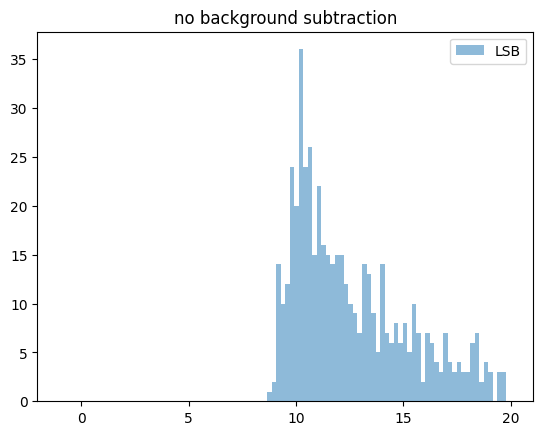

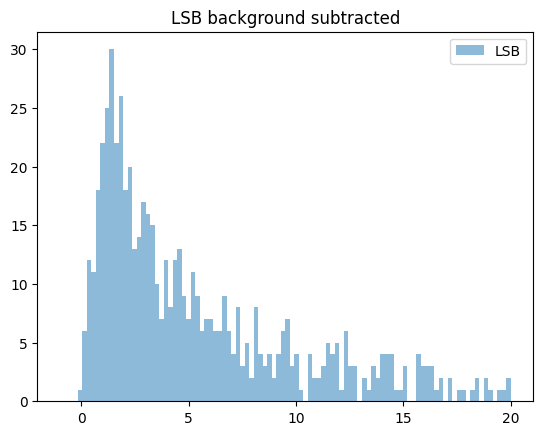

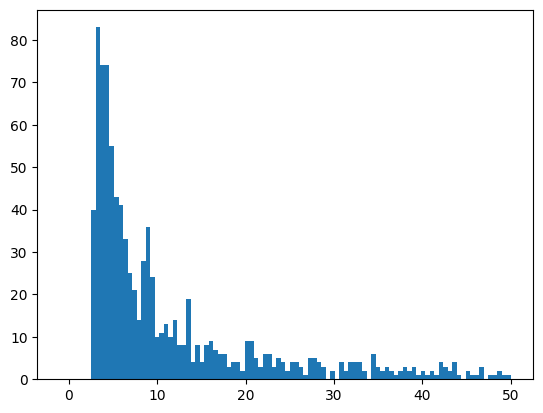

In [9]:
plt.hist(dataA[300,:], range=(-1,20), bins=100, alpha=0.5, label='LSB')
plt.legend()
plt.title('no background subtraction')
plt.show()

plt.hist(dataA[300,:]-8.874471671787974, range=(-1,20), bins=100, alpha=0.5, label='LSB')
plt.legend()
plt.title('LSB background subtracted')
plt.show()

plt.hist(dataNGC[780,:], range=(-1, 50), bins=100)
plt.show()

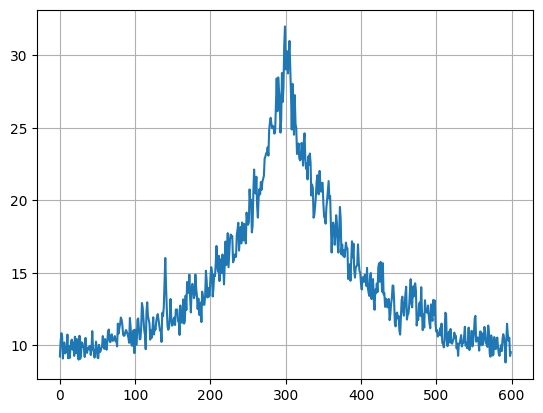

In [13]:
plt.plot(range(len(dataA[300,:])), dataA[300,:])
plt.grid()
plt.show()